In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
con

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  41.26132396111801
Gradient descend method:  None
RUN  1 , total integrated cost =  14.374260822718798
RUN  2 , total integrated cost =  13.226790690869361
RUN  3 , total integrated cost =  13.212485729669709
RUN  4 , total integrated cost =  13.192824336893969
RUN  5 , total integrated cost =  13.17619240890401
RUN  6 , total integrated cost =  13.165834404501362
RUN  7 , total integrated cost =  13.157286916756712
RUN  8 , total integrated cost =  13.146608176942586
RUN  9 , total integrated cost =  13.137304783632901
RUN  10 , total integrated cost =  13.1308109293249
RUN  11 , total integrated cost =  13.125560830369048
RUN  12 , total integrated cost =  13.118898858714651
RUN  13 , total integrated cost =  13.113781574568389
RUN  14 , total integrated cost =  13.10929465590111
RUN  15 , total integrated cost =  13.105714925064959
RU

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  123.03576666232681
RUN  1000 , total integrated cost =  123.03576666232681
Improved over  1000  iterations in  187.44782531633973  seconds by  4.9326049005932475  percent.
Problem in initial value trasfer:  Vmean_exc -56.627685034405346 -56.62768135021969
weight =  4796.309464846601
set cost params:  1.0 0.0 4796.309464846601
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5898.861291959985
Gradient descend method:  None
RUN  1 , total integrated cost =  5882.397274539244
RUN  2 , total integrated cost =  5881.174853890283
RUN  3 , total integrated cost =  5879.236551666959
RUN  4 , total integrated cost =  5878.630138087501
RUN  5 , total integrated cost =  5877.823302222608
RUN  6 , total integrated cost =  5877.231777837831
RUN  7 , total integrated cost =  5876.533324797784
RUN  8 , total integrated cost =  5875.834118607585
RUN  9 , total integrated cost =  5874.968764559457
RUN  10 , total integrated cost =  5874.426412

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  5332.32835395514
RUN  1000 , total integrated cost =  5332.32835395514
Improved over  1000  iterations in  133.36365678720176  seconds by  9.60410679222133  percent.
Problem in initial value trasfer:  Vmean_exc -56.62733419404746 -56.627336325849726
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40.25142203550361
Gradient descend method:  None
RUN  1 , total integrated cost =  12.64100730718415
RUN  2 , total integrated cost =  12.62442170321223
RUN  3 , total integrated cost =  12.612353994422131
RUN  4 , total integrated cost =  12.60323140754305
RUN  5 , total integrated cost =  12.595979432308548
RUN  6 , total integrated cost =  12.590604131602964
RUN  7 , total integrated cost =  12.58582146030883
RUN  8 , total integrated cost =  12.582419182469604
RUN  9 , total integrated cost =  12.57911338488984
RUN  10 , total integrated cost =  12.5

...

RUN  4 , total integrated cost =  14440.026546534837
Control only changes marginally.
RUN  4 , total integrated cost =  14440.026546534837
Improved over  4  iterations in  1.7214607782661915  seconds by  1.1034354372441157e-06  percent.
Problem in initial value trasfer:  Vmean_exc -56.67681612037517 -56.67681651959775
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  77.86616842577496
Gradient descend method:  None
RUN  1 , total integrated cost =  77.21345355341393
RUN  2 , total integrated cost =  77.21280535247666
RUN  3 , total integrated cost =  77.21179335732688
RUN  4 , total integrated cost =  77.21114770059611
RUN  5 , total integrated cost =  77.2099098694705
RUN  6 , total integrated cost =  77.20892415466436
RUN  7 , total integrated cost =  77.2062839500555
RUN  8 , total integrated cost =  77.20419424867623
RUN  9 , total integrated cost =  77.19634958564741
RUN  10 , t

ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  769.046845478067
Control only changes marginally.
RUN  11 , total integrated cost =  769.046845478067
Improved over  11  iterations in  3.718779493123293  seconds by  0.001804426897393796  percent.
Problem in initial value trasfer:  Vmean_exc -56.6516102142204 -56.651611257460296
weight =  1301.9074337277204
set cost params:  1.0 0.0 1301.9074337277204
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10012.07870079967
Gradient descend method:  None
RUN  1 , total integrated cost =  10011.32518841449
RUN  2 , total integrated cost =  10011.324978725706
RUN  3 , total integrated cost =  10011.324970121332
RUN  4 , total integrated cost =  10011.324969115061
RUN  5 , total integrated cost =  10011.324968933295
RUN  6 , total integrated cost =  10011.324968902287
RUN  7 , total integrated cost =  10011.32496889606
RUN  8 , total integrated cost =  10011.32496889485
RUN  9 , total integrated cost =  10011.324968894623
RUN  10 , total

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  10011.324968894562
Control only changes marginally.
RUN  13 , total integrated cost =  10011.324968894562
Improved over  13  iterations in  4.189483722671866  seconds by  0.007528225932219357  percent.
Problem in initial value trasfer:  Vmean_exc -56.65151613272395 -56.65151876820865


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


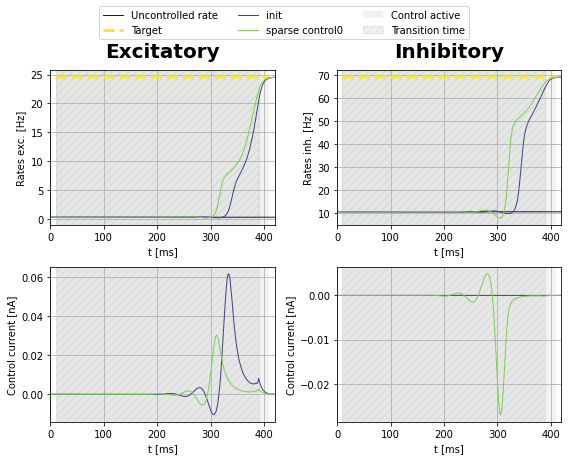

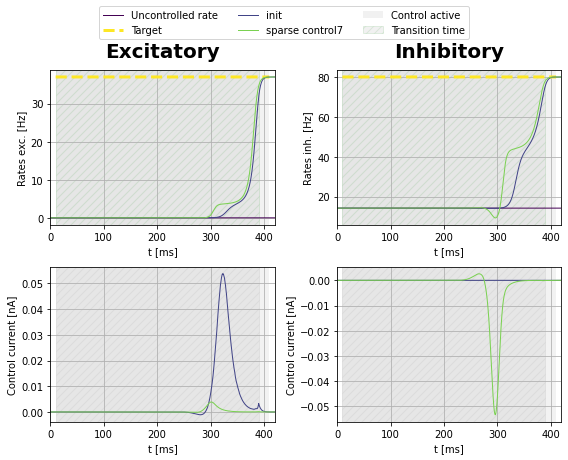

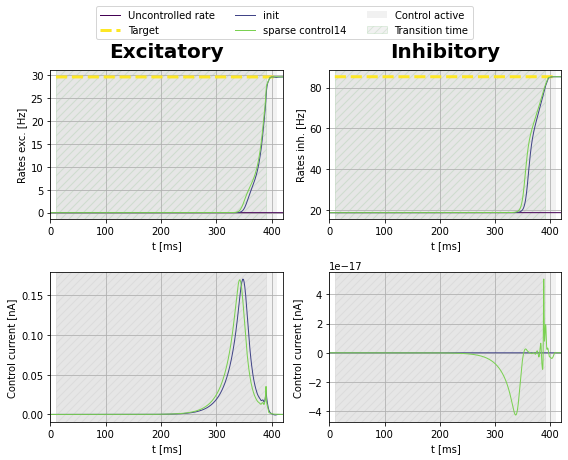

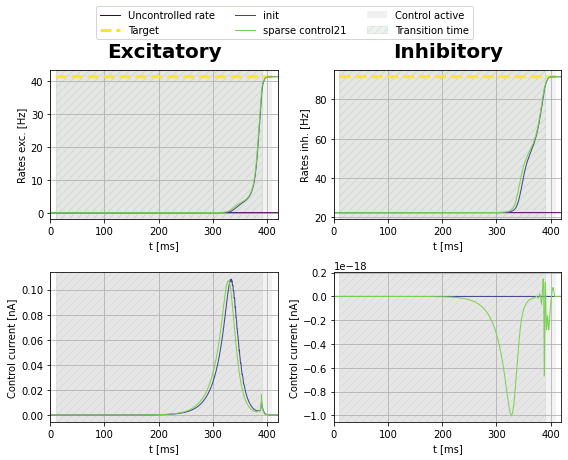

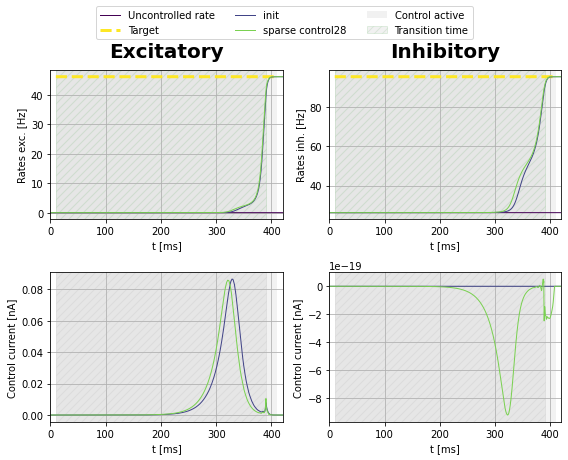

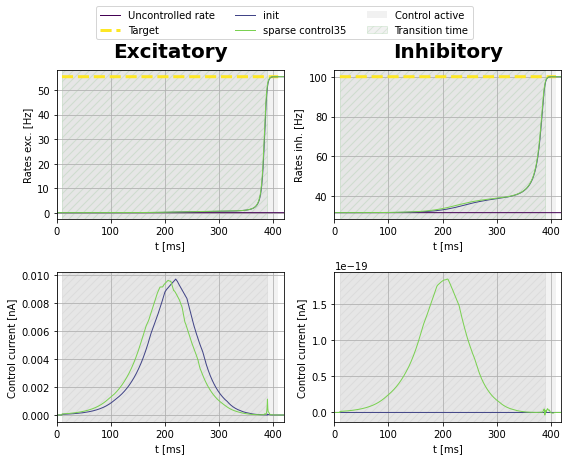

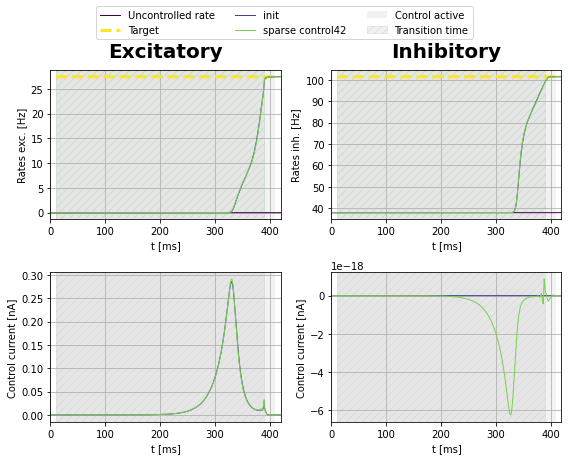

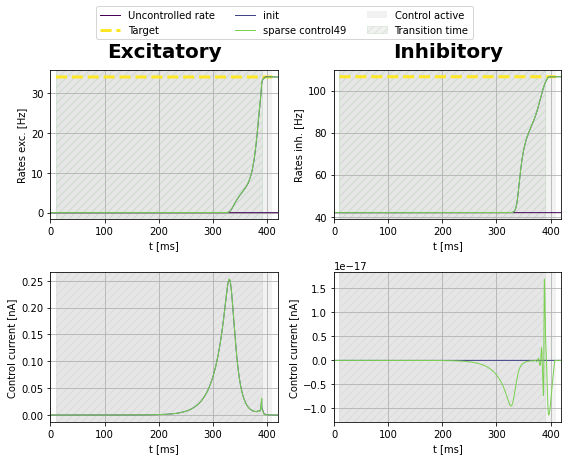

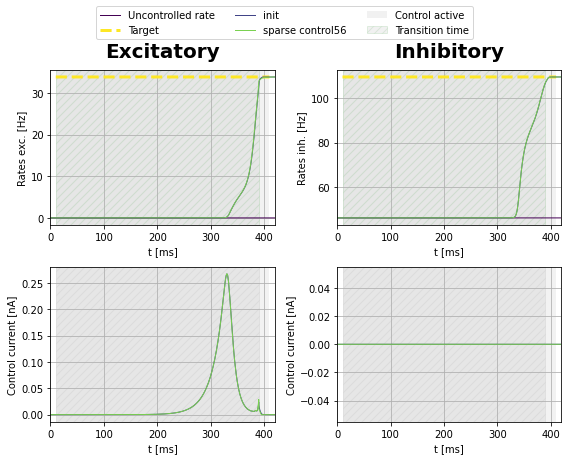

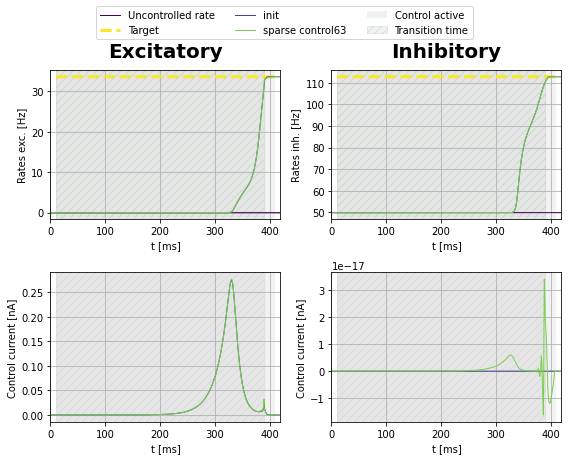

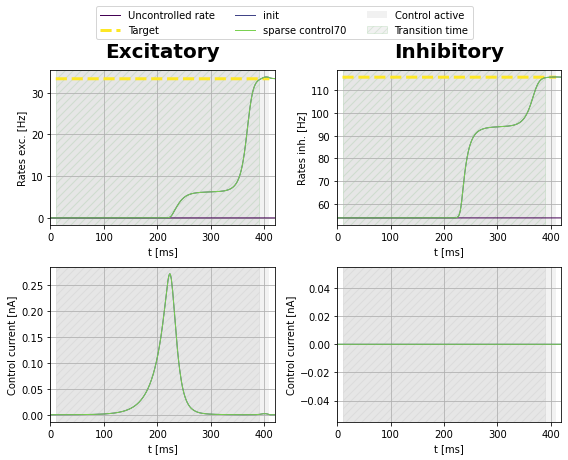

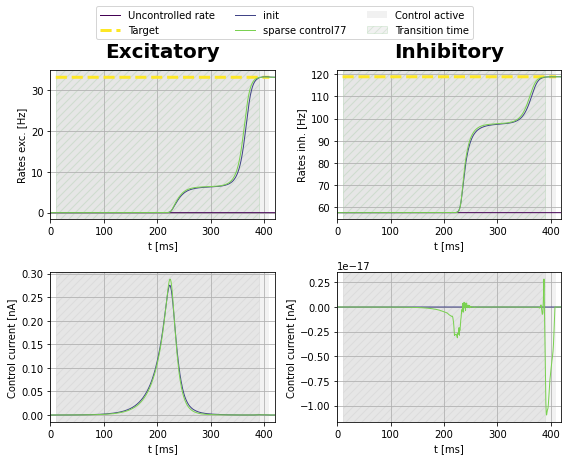

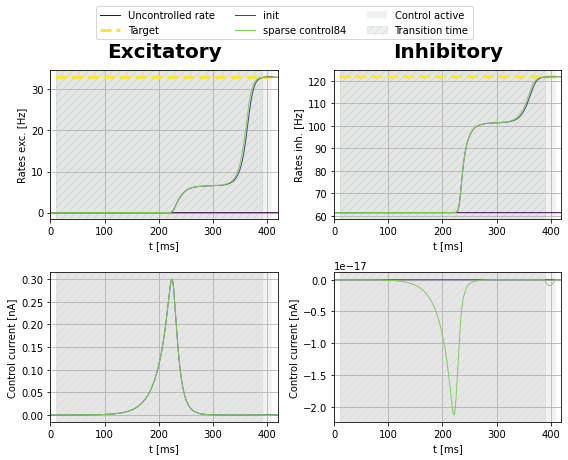

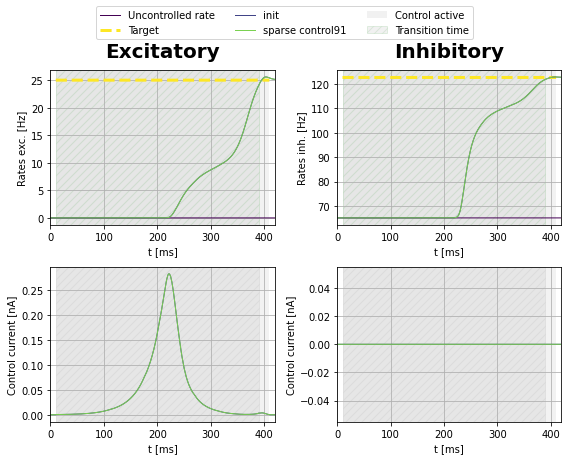

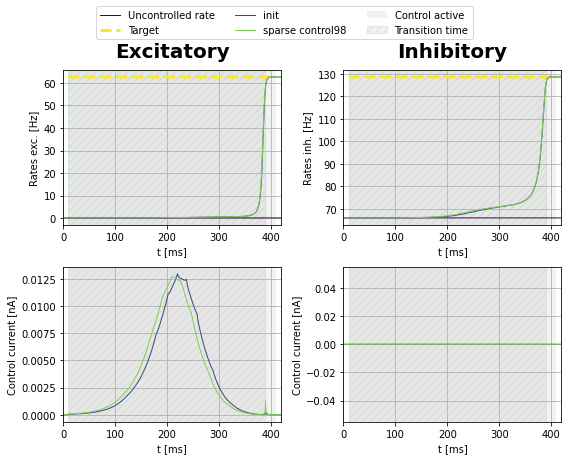

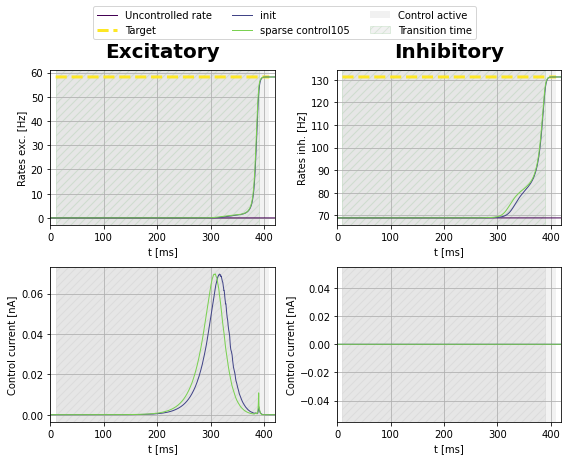

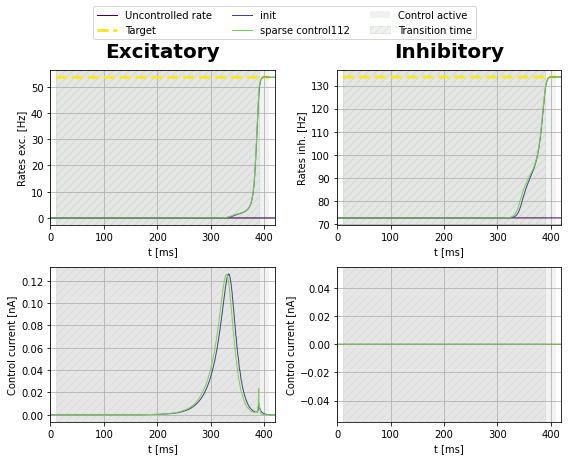

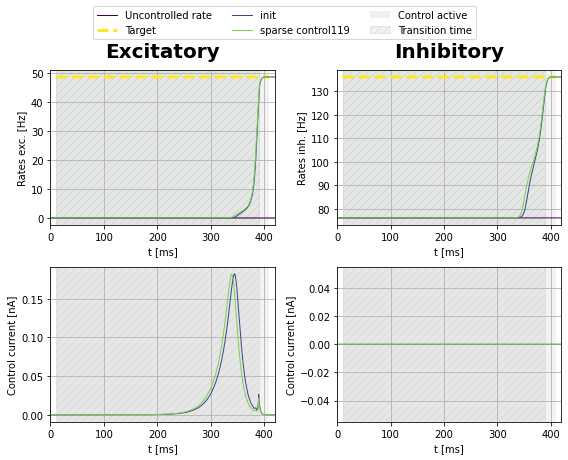

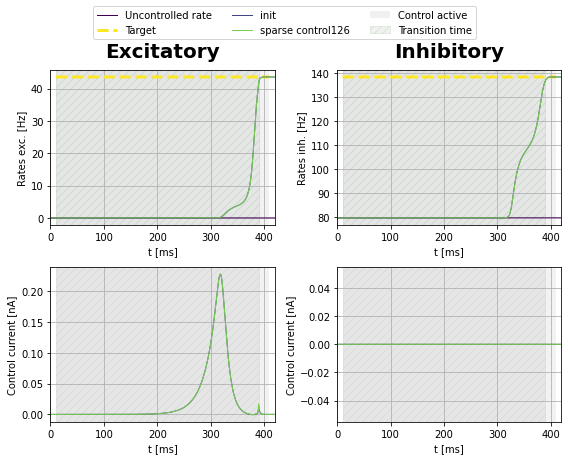

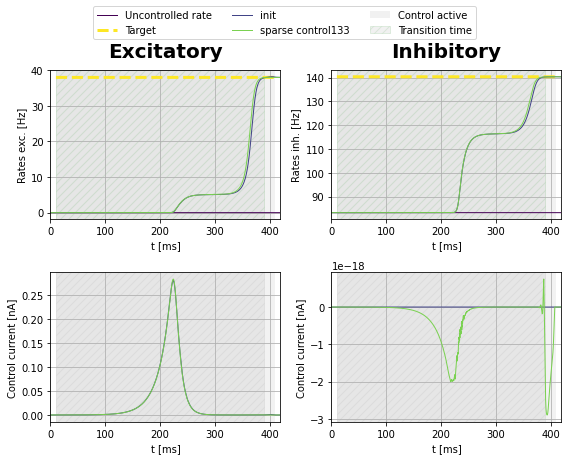

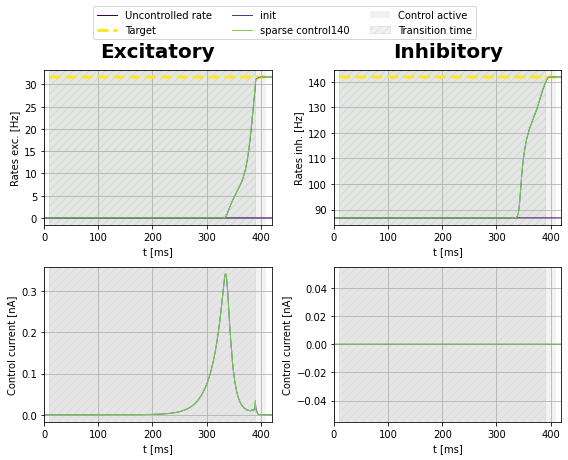

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5308.08192117329
set cost params:  1.0 0.0 5308.08192117329
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.208739051789
Gradient descend method:  None
RUN  1 , total integrated cost =  5898.9699401157895
RUN  2 , total integrated cost =  5898.290720732148
RUN  3 , total integrated cost =  5897.399218292669
RUN  4 , total integrated cost =  5896.733989859543
RUN  5 , total integrated cost =  5896.021280076214
RUN  6 , total integrated cost =  5895.355598356337
RUN  7 , total integrated cost =  5894.760971059745
RUN  8 , total integrated

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1061 , total integrated cost =  5054.040393687002
Improved over  1061  iterations in  143.56321118958294  seconds by  14.34132897306229  percent.
Problem in initial value trasfer:  Vmean_exc -56.62695453176715 -56.6269590877941
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  12825.14468663364
set cost params:  1.0 0.0 12825.14468663364
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13555.219248383995
Gradient descend method:  None
RUN  1 , total integrated cost =  13552.295607252734
RUN  2 , total integrated cost =  13549.662876422717
RUN  3 , total integrated cost =  13549.525609033553
RUN  4 , total integrated cost =  13549.291677464116
RUN  5 , total integrated cost =  13549.005202204205
RUN  6 , total integrated cost =  13548.767339179904
RUN  7 , total integrated cost =  13548.493927688616
RUN  8 , total integrated cost =  13548.260243534973
RUN  9 , total integrated cost =  13547.97301452282

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  888 , total integrated cost =  13317.068007232854
Improved over  888  iterations in  122.93858325108886  seconds by  1.7568970061442002  percent.
Problem in initial value trasfer:  Vmean_exc -56.67411843091075 -56.67411966898882
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2182.85856355915
set cost params:  1.0 0.0 2182.85856355915
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8792.140266204806
Gradient descend method:  None
RUN  1 , total integrated cost =  8792.140265394579
RUN  2 , total integrated cost =  8792.1402650694
RUN  3 , total integrated cost =  8792.140264928043
RUN  4 , total integrated cost =  8792.140264868187
RUN  5 , total integrated cost =  8792.140264841715
RUN  6 , total integrated cost =  8792.140264829812
RUN  7 , total integrated cost =  8792.14026482435
RUN  8 , total integrated cost =  8792.14026482186
RUN  9 , total integrated cost =  8792.140264820704
RUN  10 , tot

...

RUN  1 , total integrated cost =  5901.441514905087
Control only changes marginally.
RUN  1 , total integrated cost =  5901.441514905087
Improved over  1  iterations in  0.4821823872625828  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62692630676216 -56.626931145331525
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  13055.50270326826
set cost params:  1.0 0.0 13055.50270326826
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13556.166722671884
Gradient descend method:  None
RUN  1 , total integrated cost =  13556.16672267185
RUN  2 , total integrated cost =  13556.16672267184
RUN  3 , total integrated cost =  13556.166722671815
RUN  4 , total integrated cost =  13556.166722671811


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  13556.166722671811
Control only changes marginally.
RUN  5 , total integrated cost =  13556.166722671811
Improved over  5  iterations in  2.0019763093441725  seconds by  5.400124791776761e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.67411797115028 -56.674119220906675
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13556.166760027776
Control only changes marginally.
RUN  1 , total integrated cost =  13556.166760027776
Improved over  1  iterations in  0.5016986466944218  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67411797115028 -56.674119220906675
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.450

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.3749486515917
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0181653089602627
RUN  2 , total integrated cost =  1.0097710431286009
RUN  3 , total integrated cost =  1.0085943832446118
RUN  4 , total integrated cost =  1.0077068046595312
RUN  5 , total integrated cost =  1.0069914132606606
RUN  6 , total integrated cost =  1.0063741858281354
RUN  7 , total integrated cost =  1.0058191951660285
RUN  8 , total integrated cost =  1.0052700399097438
RUN  9 , total integrated cost =  1.0047430438931486
RUN  10 , total integrated cost =  1.0041528788743213
RUN  11 , total integrated cost =  1.0035829848362814
RUN  12 , total integrated cost =  1.003026667882281
RUN  13 , total integrated cost =  1.0024643439934282
RUN  14 , total integrated cost =  1.0018347954150408
RUN  15 , total integrated cost =  1.0012281130674852
R

RUN  90 , total integrated cost =  2.7286691883711938
RUN  100 , total integrated cost =  2.728143004124876
RUN  110 , total integrated cost =  2.72767517903754
RUN  120 , total integrated cost =  2.7272648382646634
RUN  130 , total integrated cost =  2.7268926885341602
RUN  140 , total integrated cost =  2.7265677689710865
RUN  150 , total integrated cost =  2.726277688063734
RUN  160 , total integrated cost =  2.7260285795817794
RUN  170 , total integrated cost =  2.725804968455204
RUN  180 , total integrated cost =  2.725611093622599
RUN  190 , total integrated cost =  2.7254331168432127
RUN  200 , total integrated cost =  2.7252753674507435
RUN  300 , total integrated cost =  2.7243091573340825
RUN  400 , total integrated cost =  2.7238648455494077
RUN  500 , total integrated cost =  2.7236551607290327
RUN  600 , total integrated cost =  2.7235671635144447
RUN  700 , total integrated cost =  2.7234618900084953
RUN  800 , total integrated cost =  2.7229368598121386
RUN  900 , total 

RUN  6 , total integrated cost =  6.790661272889493
RUN  7 , total integrated cost =  6.79063769460921
RUN  8 , total integrated cost =  6.790622925503057
RUN  9 , total integrated cost =  6.790565736954859
RUN  10 , total integrated cost =  6.790516934125233
RUN  11 , total integrated cost =  6.7806574674531195
RUN  12 , total integrated cost =  6.780444990362846
RUN  13 , total integrated cost =  6.780347348865616
RUN  14 , total integrated cost =  6.7802374700690775
RUN  15 , total integrated cost =  6.780108596431116
RUN  16 , total integrated cost =  6.779983927603732
RUN  17 , total integrated cost =  6.779883828555153
RUN  18 , total integrated cost =  6.779780544821823
RUN  19 , total integrated cost =  6.779673942874512
RUN  20 , total integrated cost =  6.77957064998144
RUN  30 , total integrated cost =  6.778710792582143
RUN  40 , total integrated cost =  6.778036540427062
RUN  50 , total integrated cost =  6.777453857849943
RUN  60 , total integrated cost =  6.7769996989940

RUN  50 , total integrated cost =  6.30828232656398
RUN  60 , total integrated cost =  6.308000442925577
RUN  70 , total integrated cost =  6.307755911352614
RUN  80 , total integrated cost =  6.307524481670318
RUN  90 , total integrated cost =  6.307250827601611
RUN  100 , total integrated cost =  6.306653012018588
RUN  110 , total integrated cost =  6.306487163351822
RUN  120 , total integrated cost =  6.306281516924069
RUN  130 , total integrated cost =  6.306167503678129
RUN  140 , total integrated cost =  6.3061091977154655
RUN  150 , total integrated cost =  6.306010792060743
RUN  160 , total integrated cost =  6.305933661546613
RUN  170 , total integrated cost =  6.305870472612758
RUN  180 , total integrated cost =  6.305837574315238
RUN  190 , total integrated cost =  6.305822356708027
RUN  200 , total integrated cost =  6.305807300516537
RUN  300 , total integrated cost =  6.3055352375739515
RUN  400 , total integrated cost =  6.3053823114895255
RUN  500 , total integrated cos

ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  10.756601516115843
Control only changes marginally.
RUN  1 , total integrated cost =  10.756601516115843
Improved over  1  iterations in  0.18974434025585651  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62733606480403 -56.627319275293104
-------  98 0.6000000000000003 0.7500000000000004
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.110416389533151
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5475816759281447
RUN  2 , total integrated cost =  0.5474491356814052
RUN  3 , total integrated cost =  0.547446129498148
RUN  4 , total integrated cost =  0.5474433454801667
RUN  5 , total integrated cost =  0.5474384048805485
RUN  6 , total integrated cost =  0.5474335896952953
RUN  7 , total integrated cost =  0.5474126485993768
RUN  8 , total integrated cost =  0.5473927966912422
RUN  9 , total integrated cost =  0.547316015278503
RUN  10 , total integ

RUN  70 , total integrated cost =  3.2740692611802102
RUN  80 , total integrated cost =  3.2702194294014824
RUN  90 , total integrated cost =  3.270057097335207
RUN  100 , total integrated cost =  3.269921780621938
RUN  110 , total integrated cost =  3.2698300824983835
RUN  120 , total integrated cost =  3.269784368472983
RUN  130 , total integrated cost =  3.2696688682353447
RUN  140 , total integrated cost =  3.2694389504439534
RUN  150 , total integrated cost =  3.2692858201589705
RUN  160 , total integrated cost =  3.2691602999757894
RUN  170 , total integrated cost =  3.2690482049099416
RUN  180 , total integrated cost =  3.268945665517092
RUN  190 , total integrated cost =  3.2688517994437007
RUN  200 , total integrated cost =  3.268766678111016
RUN  300 , total integrated cost =  3.268145728277887
RUN  400 , total integrated cost =  3.2678490008163803
RUN  500 , total integrated cost =  3.2676659428710866
RUN  600 , total integrated cost =  3.267556278834931
RUN  700 , total int

RUN  1100 , total integrated cost =  5.509321788796067
RUN  1200 , total integrated cost =  5.509277139899067
RUN  1300 , total integrated cost =  5.509229197396337
RUN  1400 , total integrated cost =  5.509190183125044
RUN  1500 , total integrated cost =  5.509156979229158
RUN  1600 , total integrated cost =  5.509083354475156
RUN  1700 , total integrated cost =  5.5089700615161945
RUN  1800 , total integrated cost =  5.508825858723547
RUN  1900 , total integrated cost =  5.508825044308683
RUN  2000 , total integrated cost =  5.508824305473344
RUN  3000 , total integrated cost =  5.508747834467465
Control only changes marginally.
RUN  3812 , total integrated cost =  5.50867491250247
Improved over  3812  iterations in  256.3830888401717  seconds by  17.1465471571631  percent.
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.594483456215408
Gradient descend method:  None
RUN  1 , t

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  6.594340778762153
RUN  6 , total integrated cost =  6.594340778762152
RUN  7 , total integrated cost =  6.594340778762152
Control only changes marginally.
RUN  7 , total integrated cost =  6.594340778762152
Improved over  7  iterations in  0.7237838488072157  seconds by  0.002163588008102124  percent.
Problem in initial value trasfer:  Vmean_exc -56.676816420471646 -56.67681681247479
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.480811273537409
Gradient descend method:  None
RUN  1 , total integrated cost =  7.701760085661109
RUN  2 , total integrated cost =  7.700654170191941
RUN  3 , total integrated cost =  7.700628840524006
RUN  4 , total integrated cost =  7.700607309740401
RUN  5 , total integrated cost =  7.700537539818018
RUN  6 , total integrated cost =  7.700477986769545
RUN  7 , total integrated cost =  7.700323493413849
RUN  8 , tota

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9863163737979106
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9863163737979106
Control only changes marginally.
RUN  1 , total integrated cost =  0.9863163737979106
Improved over  1  iterations in  0.16680137813091278  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0449487620007167
Gradient descend method:

RUN  19 , total integrated cost =  6.304232528202938
RUN  20 , total integrated cost =  6.304232516689115
RUN  30 , total integrated cost =  6.304232091532576
RUN  40 , total integrated cost =  6.304232078740705
RUN  50 , total integrated cost =  6.304231991707996
RUN  60 , total integrated cost =  6.3042319044187956
RUN  70 , total integrated cost =  6.304231842603153
RUN  80 , total integrated cost =  6.304231831227541
RUN  90 , total integrated cost =  6.304231744384562
RUN  100 , total integrated cost =  6.304231657588015
RUN  110 , total integrated cost =  6.304231623297292
RUN  120 , total integrated cost =  6.304231581050475
RUN  130 , total integrated cost =  6.304231569195701
RUN  140 , total integrated cost =  6.304231482557127
RUN  150 , total integrated cost =  6.304231450050353
RUN  160 , total integrated cost =  6.304231436472539
RUN  170 , total integrated cost =  6.304226381372058
RUN  180 , total integrated cost =  6.30422190602455
RUN  190 , total integrated cost =  6

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6.896275663723698
Control only changes marginally.
RUN  1 , total integrated cost =  6.896275663723698
Improved over  1  iterations in  0.1909983679652214  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6582189038051 -56.658214221109574
-------  84 0.4500000000000001 0.7250000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.006582063106464
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.006582063106464
Control only changes marginally.
RUN  1 , total integrated cost =  7.006582063106464
Improved over  1  iterations in  0.2323509156703949  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65711346882458 -56.65711398439055
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.546864539251543
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5468645392515428
RUN  2 , total integrated cost =  0.546864539251542
RUN  3 , total integrated cost =  0.5468645392515409
RUN  4 , total integrated cost =  0.5468645392515409
Control only changes marginally.
RUN  4 , total integrated cost =  0.5468645392515409
Improved over  4  iterations in  0.43728433176875114  seconds by  3.836930773104541e-13  percent.
-------  105 0.5750000

ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.676816420471646 -56.67681681247479
-------  140 0.4500000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.690761439431608
Gradient descend method:  None
RUN  1 , total integrated cost =  7.690761439431608
Control only changes marginally.
RUN  1 , total integrated cost =  7.690761439431608
Improved over  1  iterations in  0.17183332331478596  seconds by  0.0  percent.
--------------- 19
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, False], [False, False], [False, False], [True, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged fo

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
